In [1]:
import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.preprocess_behavior import *
from utils.preprocess_thorsync import *
from utils.preprocess_neural import *

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import numpy.ma as ma
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import subprocess

%matplotlib widget

# Good Sessions CKII:
[pAce21/2025-08-06_pAce21_PR/Awake](/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake)

[pAce38/2025-11-26_pAce38/PX/post/Awake](/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake)

[pAce37/2025-11-12_pAce37_BR/post/Awake](/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake)


In [3]:
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-06-30_pAce21_PR/Awake'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-10_pAce9-PX/post-cement/awake/fov1'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake' # Finished
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce19/2025-04-21_pAce19/PX/Awake/FOV1' # problem with behavior

#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce17/2025-03-26_pAce17/PX/short-lens/post-cement/Awake' # Good

#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce45/2026-01-18_pAce45/PX/post/Awake'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce28/2025-08-11-pAce28/Awake'
main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake'

######## Interneurons ########
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce17/2025-03-26_pAce17/PX/short-lens/post-cement/Awake'  # WT
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-10_pAce9-PX/post-cement/awake/fov1' # SST INs

#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-13_pAce9_WX/Awake' # SST INs


subfolders = [os.path.join(main_data_folder, f) for f in os.listdir(main_data_folder) if os.path.isdir(os.path.join(main_data_folder, f)) and f.endswith('-good')]
subfolders.sort()
print(subfolders)

['/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/2-good', '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/3-good']


In [4]:
# --- Concatenated demix support (optional) ---
USE_CONCAT_DEMIX = True

concat_root = os.path.join(main_data_folder, 'output_concat')
concat_manifest_path = os.path.join(concat_root, 'concat_raw_manifest.json')

demix_by_session = None
frames_truncated = 500  # default (used for thorsync alignment)

if USE_CONCAT_DEMIX:
    import glob

    manifest = load_concat_raw_manifest(concat_manifest_path)
    frames_truncated = int(manifest.get('frames_to_truncate_per_session', 500))
    session_edges_frames = manifest.get('session_edges_frames', None)

    # Prefer annotated results if present
    candidates = []
    candidates += glob.glob(os.path.join(concat_root, 'output_final', '*', 'volpy_demix_results_annotated.pickle'))
    candidates += glob.glob(os.path.join(concat_root, 'output_final', '*', 'volpy_demix_results.pickle'))
    candidates += glob.glob(os.path.join(concat_root, 'volpy_demix_results_annotated.pickle'))
    candidates += glob.glob(os.path.join(concat_root, 'volpy_demix_results.pickle'))

    if not candidates:
        raise FileNotFoundError(f'No volpy demix results found under: {concat_root}')

    concat_demix_path = candidates[0]
    print('Using concatenated demix:', concat_demix_path)

    with open(concat_demix_path, 'rb') as f:
        concat_results = pickle.load(f)

    split_sessions = split_concatenated_volpy_results(
        concat_results,
        session_edges_frames,
        frame_rate_hz=manifest.get('frame_rate_hz', None),
    )

    session_folders_manifest = [s.get('session_good_folder_local', '') for s in manifest.get('sessions_local', [])]
    if any([not p for p in session_folders_manifest]) or len(session_folders_manifest) != len(split_sessions):
        print('[WARN] Could not map manifest sessions to -good folders; falling back to subfolders order.')
        session_folders_manifest = list(subfolders)[:len(split_sessions)]

    demix_by_session = {sf: d for sf, d in zip(session_folders_manifest, split_sessions)}

    # Ensure subfolders follow concatenation order (important for later merging)
    subfolders = [sf for sf in session_folders_manifest if sf in subfolders] + [sf for sf in subfolders if sf not in session_folders_manifest]

    print('Using subfolders order:', subfolders)
    print('frames_truncated:', frames_truncated)


Using concatenated demix: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/output_concat/output_final/concat_mc/volpy_demix_results_annotated.pickle
Using subfolders order: ['/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/2-good', '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/3-good']
frames_truncated: 500


# Behavior refinement

### Run the next 2 cells if you haven't draw a rectangle ROI yet

Processing folder: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/2-good
Video dimensions: 1388x872, FPS: 20.0, Total frames: 12020
pixel to cm ratio=39.10 (width), 43.60 (height)
Using filtered DLC file: Flir-02222026114019-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered.csv
Frames with no valid best position: 36/12020 (0.3%)
Frames with no valid second position: 85/12020 (0.7%)
Processing folder: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/3-good
Video dimensions: 1388x872, FPS: 20.0, Total frames: 12020
pixel to cm ratio=39.10 (width), 43.60 (height)
Using filtered DLC file: Flir-02222026115152-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered.csv
Frames with no valid best position: 182/12020 (1.5%)
Frames with no valid second position: 417/12020 (3.5%)


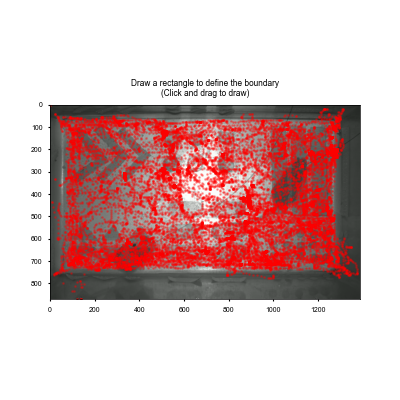

In [5]:
# Behavior refinement
width_real = 35.5  # cm
height_real = 20  # cm
frames = []
x_all = []
y_all = []
for data_folder in subfolders:
    print(f"Processing folder: {data_folder}")
    frame_width, frame_height, ratio_width, ratio_height, video_fps, video_n_frames, frame_rgb = get_behav_video_dimensions(data_folder, width_real, height_real, sample_frame_idx=100)
    frames.append(frame_rgb)
    df = read_DLC_csv_file(data_folder)
    df_refined = refine_headpositions(df, thr_likelihood_head=0.5, thr_likelihood_nose=0.5, filter_kernel_size=3)
    x_all.append(df_refined['head_best_x'].to_numpy())
    y_all.append(df_refined['head_best_y'].to_numpy())

frames = np.array(frames)
x_all = np.concatenate(x_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

# Interactive rectangle drawing tool
from matplotlib.widgets import RectangleSelector
import matplotlib.patches as patches

class BoundarySelector:
    def __init__(self, frame, x_all, y_all):
        self.frame = frame
        self.x_all = x_all
        self.y_all = y_all
        self.rect_coords = None  # (x1, y1, x2, y2)
        
        self.fig, self.ax = plt.subplots(figsize=(4,4))
        self.ax.imshow(frame)
        self.scatter = self.ax.scatter(x_all, y_all, s=1, c='red', alpha=0.3)
        self.ax.set_title('Draw a rectangle to define the boundary\n(Click and drag to draw)')
        
        self.rect_selector = RectangleSelector(
            self.ax, self.on_select,
            useblit=True,
            button=[1],  # Left mouse button
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True
        )
        plt.show()
    
    def on_select(self, eclick, erelease):
        x1, y1 = eclick.xdata, eclick.ydata
        x2, y2 = erelease.xdata, erelease.ydata
        self.rect_coords = (min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2))
        print(f"Selected boundary: x=[{self.rect_coords[0]:.1f}, {self.rect_coords[2]:.1f}], "
              f"y=[{self.rect_coords[1]:.1f}, {self.rect_coords[3]:.1f}]")

# Use the mean frame for drawing
mean_frame = np.mean(frames, axis=0).astype(np.uint8)

# Create the interactive selector
%matplotlib widget
selector = BoundarySelector(mean_frame, x_all, y_all)

In [6]:
if selector.rect_coords is not None:
    x_min, y_min, x_max, y_max = selector.rect_coords
    print(f"Using drawn boundary: x=[{x_min:.1f}, {x_max:.1f}], y=[{y_min:.1f}, {y_max:.1f}]")
else:
    # Manual fallback - adjust these values based on your video
    x_min, y_min, x_max, y_max = 50, 50, 600, 400  # Example values
    print(f"Using manual boundary: x=[{x_min:.1f}, {x_max:.1f}], y=[{y_min:.1f}, {y_max:.1f}]")

boundary_box = (x_min, y_min, x_max, y_max)

import json
# Save boundary_box in each subfolder for downstream steps
boundary_path = "boundary_box.json"
for folder in subfolders:
    save_path = os.path.join(folder, boundary_path)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump({"boundary_box": boundary_box}, f)
    print(f"Saved boundary_box to {save_path}")

Using drawn boundary: x=[12.9, 1351.7], y=[32.5, 775.8]
Saved boundary_box to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/2-good/boundary_box.json
Saved boundary_box to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/3-good/boundary_box.json


# Process all good subfolders to align neural and behavior data

Video dimensions: 1388x872, FPS: 20.0, Total frames: 12020
pixel to cm ratio=39.10 (width), 43.60 (height)
Using filtered DLC file: Flir-02222026114019-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered.csv
Frames with no valid best position: 120/12020 (1.0%)
Frames with no valid second position: 262/12020 (2.2%)
Total FLIR frames detected: 12076
Total FrameOut2 peaks detected: 301049
Original traces shape: (299500, 18)
Traces shape: (9, 299500)
Spikes shape: (9,)


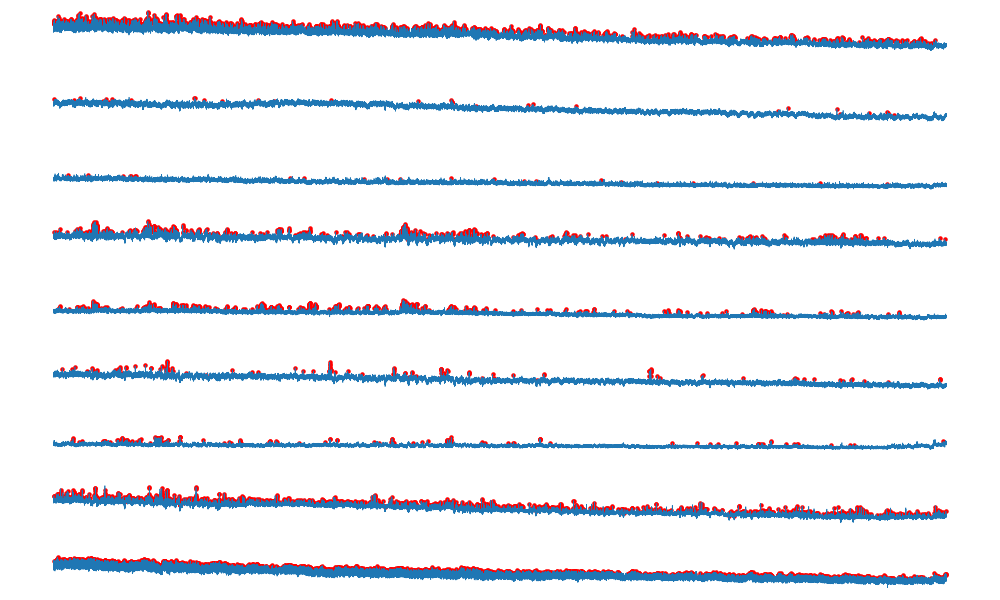

ts_behav length is now 12020 and starts at 2139.00 ms, ends at 603089.00 ms
Neural data ends at 603573.50 ms, behavior data ends at 603089.00 ms
There are 484.50 ms of neural data without the behaviral data at the end.
Neural data truncated from 299500 to 299257 frames.
Aligned data saved to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/2-good/aligned_data.pkl
Video dimensions: 1388x872, FPS: 20.0, Total frames: 12020
pixel to cm ratio=39.10 (width), 43.60 (height)
Using filtered DLC file: Flir-02222026115152-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered.csv
Frames with no valid best position: 400/12020 (3.3%)
Frames with no valid second position: 1554/12020 (12.9%)
Total FLIR frames detected: 12031
Total FrameOut2 peaks detected: 300010
Original traces shape: (299500, 18)
Traces shape: (9, 299500)
Spikes shape: (9,)


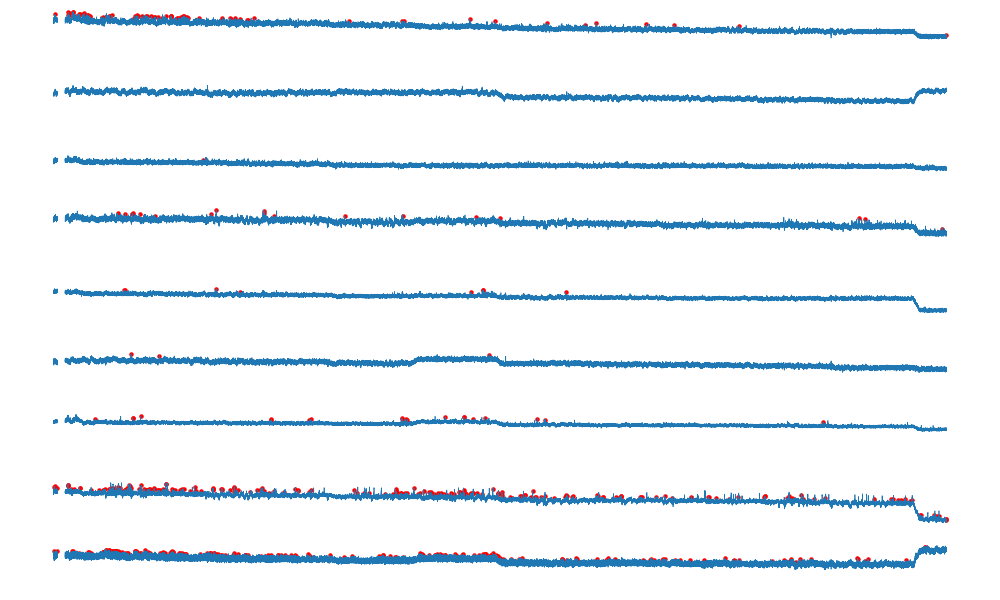

ts_behav length is now 12020 and starts at 2383.13 ms, ends at 603333.13 ms
Neural data ends at 603688.23 ms, behavior data ends at 603333.13 ms
There are 355.10 ms of neural data without the behaviral data at the end.
Neural data truncated from 299500 to 299322 frames.
Aligned data saved to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/3-good/aligned_data.pkl


In [8]:
width_real = 35.5  # cm
height_real = 20  # cm
for data_folder in subfolders:
    frame_width, frame_height, ratio_width, ratio_height, video_fps, video_n_frames, frame_rgb = get_behav_video_dimensions(data_folder, width_real, height_real, sample_frame_idx=100)
    df = read_DLC_csv_file(data_folder)
    df_refined, x, y, positions = refine_headpositions(df, data_folder=data_folder, width_real=width_real, height_real=height_real, thr_likelihood_head=0.6, thr_likelihood_nose=0.6, filter_kernel_size=1, short_gap_max_frames=5, interpolate_remaining_nan=False, include_body=False)
    hd_angles = df_refined['head_direction_deg'].to_numpy().squeeze()   
    thorsync_data = read_thorsync_file(data_folder, plotflag=False)
    if USE_CONCAT_DEMIX and (demix_by_session is not None) and (data_folder in demix_by_session):
        traces, traces_raw, spikes, spikes_volpy, weights, ROIs, mean_image, mean_image_raw, metadata = read_Volpy_demix_results_data(demix_by_session[data_folder], plotflag=True)
    else:
        traces, traces_raw, spikes, spikes_volpy, weights, ROIs, mean_image, mean_image_raw, metadata = read_Volpy_demix_results_file(data_folder, plotflag=True)
    results_aligned = align_neural_behav_data(thorsync_data, positions, hd_angles, traces, traces_raw, spikes, spikes_volpy, ratio_width, ratio_height, metadata, frames_truncated=frames_truncated, truncate_neural=True, speed_smooth_window=100, plotflag=False)

    # add mean_image, weights, frame_width, frame_height to results_aligned
    results_aligned['mean_image'] = mean_image
    results_aligned['mean_image_raw'] = mean_image_raw
    results_aligned['weights'] = weights
    results_aligned['ROIs'] = ROIs
    results_aligned['frame_width'] = frame_width
    results_aligned['frame_height'] = frame_height

    save_path = os.path.join(data_folder, 'aligned_data.pkl')
    with open(save_path, 'wb') as f:
        pickle.dump(results_aligned, f)
    print(f"Aligned data saved to {save_path}")

    df_refined_path = os.path.join(data_folder, "behavior_refined.csv")
    df_refined.to_csv(df_refined_path, index=False)

# Merge data across sessions

In [9]:
traces_all = []
traces_raw_all = []
spikes_all = []
spikes_volpy_all = []
speed_all = []
x_neural_all = []   
y_neural_all = []
hd_angles_neural_all = []
ts_neural_all = []
weights_all = []
ROIs_all = []
mean_images = []
mean_images_raw = []

session_start_frames = []

traces_length = 0
ts_total = 0
for data_folder in subfolders:
    aligned_data = os.path.join(data_folder, 'aligned_data.pkl')
    if os.path.exists(aligned_data):
        with open(aligned_data, 'rb') as f:
            results_aligned = pickle.load(f)
        print(f"Loaded aligned data from {aligned_data}")
    else:
        print(f"No aligned data found in {data_folder}")
    
    with open(aligned_data, 'rb') as f:
        loaded_data = pickle.load(f)

    ts_neural = loaded_data['ts_neural']
    x_neural = loaded_data['x_neural']
    y_neural = loaded_data['y_neural']
    hd_angles_neural = loaded_data['hd_angles_neural']
    traces = loaded_data['traces']
    traces_raw = loaded_data['traces_raw']
    spikes = loaded_data['spikes']
    spikes_volpy = loaded_data['spikes_volpy']
    speed = loaded_data['speed']
    frame_rate = loaded_data['frame_rate']
    ts_behav = loaded_data['ts_behav']
    frames_behav = loaded_data['frames_behav']
    frames_neural = loaded_data['frames_neural']
    frame_width = loaded_data['frame_width']
    frame_height = loaded_data['frame_height']
    weights = loaded_data['weights']
    ROIs = loaded_data['ROIs']
    mean_image = loaded_data['mean_image']
    mean_image_raw = loaded_data['mean_image_raw']
    frame_rate = 500
    
    print(spikes.shape[0])

    session_start_frames.append(traces_length)
    
    traces_all.append(traces)
    traces_raw_all.append(traces_raw)
    spikes_all.append(spikes+traces_length)
    spikes_volpy_all.append(spikes_volpy+traces_length)
    speed_all.append(speed)
    x_neural_all.append(x_neural)
    y_neural_all.append(y_neural)
    hd_angles_neural_all.append(hd_angles_neural)

    ts_neural_all.append(ts_neural-ts_neural[0] + ts_total)
    
    traces_length+=traces.shape[1]
    ts_total+= ts_neural[-1] - ts_neural[0]

    weights_all.append(weights)
    ROIs_all.append(ROIs)
    mean_images.append(mean_image)
    mean_images_raw.append(mean_image_raw)



Loaded aligned data from /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/2-good/aligned_data.pkl
9
Loaded aligned data from /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/3-good/aligned_data.pkl
9


In [10]:
spikes = []
spikes_volpy = []
# for each neuron (2nd dim), merge the 4 segments of spikes (1st dim)
spikes_all = np.array(spikes_all)
for neuron in range(spikes_all.shape[1]):
    spikes.append(np.concatenate(spikes_all[:, neuron]))

spikes_volpy_all = np.array(spikes_volpy_all)
for neuron in range(spikes_volpy_all.shape[1]):
    spikes_volpy.append(np.concatenate(spikes_volpy_all[:, neuron]))

traces_all = np.concatenate(traces_all, axis=1)
# find correct concatenation for traces_raw_all
traces_raw_size = traces_raw_all[0].shape
if traces_raw_size[0] < traces_raw_size[1]:
    traces_raw_all = np.concatenate(traces_raw_all, axis=1)
else:
    traces_raw_all = np.concatenate(traces_raw_all, axis=0)
speed_all = np.concatenate(speed_all)
ts_neural_all = np.concatenate(ts_neural_all)

traces = traces_all
traces_raw = traces_raw_all
speed = speed_all
ts_trace = ts_neural_all
ts_neural = ts_neural_all

x_neural_all = np.concatenate(x_neural_all)
y_neural_all = np.concatenate(y_neural_all)
hd_angles_neural_all = np.concatenate(hd_angles_neural_all)

x_neural = x_neural_all
y_neural = y_neural_all
hd_angles_neural = hd_angles_neural_all

# If any neuron has NaN at a timepoint, set behavior data to NaN as well
nan_mask = np.any(np.isnan(traces), axis=0)  # True where any neuron has NaN
x_neural[nan_mask] = np.nan
y_neural[nan_mask] = np.nan
hd_angles_neural[nan_mask] = np.nan
speed[nan_mask] = np.nan

print(f"Number of timepoints with NaN traces: {np.sum(nan_mask)} / {len(nan_mask)}")

Number of timepoints with NaN traces: 6176 / 598579


In [11]:
# Save merged data to main_data_folder
merged_data = {
    'traces': traces,
    'traces_raw': traces_raw,
    'spikes': spikes,
    'spikes_volpy': spikes_volpy,
    'speed': speed,
    'ts_neural': ts_neural,
    'x_neural': x_neural,
    'y_neural': y_neural,
    'hd_angles_neural': hd_angles_neural,
    'frame_rate': frame_rate,
    'frame_width': frame_width,
    'frame_height': frame_height,
    'subfolders': subfolders,
    'weights_all': weights_all,
    'ROIs_all': ROIs_all,
    'mean_images': mean_images,
    'mean_images_raw': mean_images_raw,
    'session_start_frames': session_start_frames
}

save_path = os.path.join(main_data_folder, 'merged_aligned_data.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(merged_data, f)
print(f"Merged data saved to {save_path}")

Merged data saved to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/merged_aligned_data.pkl


In [12]:
# # load merged data 
# with open(save_path, 'rb') as f:
#     loaded_merged_data = pickle.load(f)
#     traces = loaded_merged_data['traces']
#     spikes = loaded_merged_data['spikes']
#     spikes_volpy = loaded_merged_data['spikes_volpy']
#     speed = loaded_merged_data['speed']
#     ts_neural = loaded_merged_data['ts_neural']
#     x_neural = loaded_merged_data['x_neural']
#     y_neural = loaded_merged_data['y_neural']
#     hd_angles_neural = loaded_merged_data['hd_angles_neural']
#     weights_all = loaded_merged_data['weights_all']
#     mean_images = loaded_merged_data['mean_images']
#     frame_rate = loaded_merged_data['frame_rate']
#     frame_width = loaded_merged_data['frame_width']
#     frame_height = loaded_merged_data['frame_height']
#     subfolders = loaded_merged_data['subfolders']
# print(f"Loaded merged data from {save_path}")

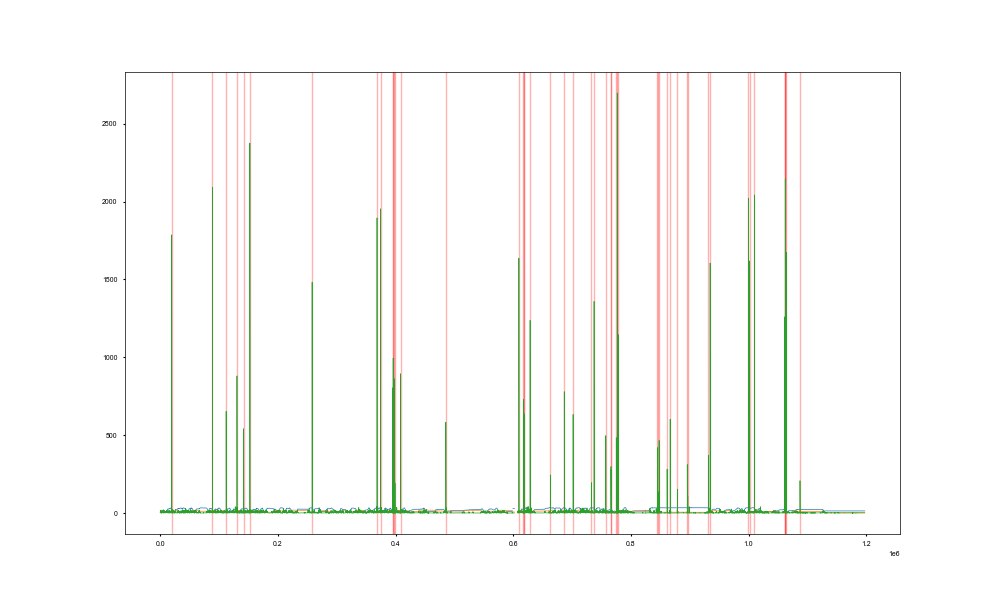

In [13]:
# detect epoch when speed pass threshold
speed_threshold = 50
remove_window = 5
epochs_outliers = detect_speed_epochs(speed, speed_threshold, min_duration=1)

fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True)
ax.plot(ts_neural, x_neural, label='Interpolated X Position', linewidth=0.5)
ax.plot(ts_neural, y_neural, label='Interpolated Y Position', linewidth=0.5)
ax.plot(ts_neural, speed, label='Speed (cm/s)', linewidth=0.5)

for start, end in epochs_outliers:
    start = ts_neural[start]
    end = ts_neural[end]
    
    ax.axvspan(start, end, color='red', alpha=0.3, label='Speed Outlier Epochs')

# set x_neural, y_neural, speed during these epochs to NaN, then interpolate to nearest values
for start, end in epochs_outliers:
    x_neural[start-remove_window:end+remove_window] = np.nan
    y_neural[start-remove_window:end+remove_window] = np.nan
    speed[start-remove_window:end+remove_window] = np.nan
x_neural = pd.Series(x_neural).interpolate(method='nearest').to_numpy()
y_neural = pd.Series(y_neural).interpolate(method='nearest').to_numpy()
speed = pd.Series(speed).interpolate(method='nearest').to_numpy()


In [14]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from scipy.ndimage import center_of_mass

# -----------------------------------------------------------------------------
# ASSUMPTIONS:
# The following variables must be defined in your environment before running:
# ts_neural: array of timestamps
# x_neural: array of x positions
# y_neural: array of y positions
# speed: array of speeds
# traces: 2D array of neural traces (cells x time)
# spikes: list of arrays, each containing indices or boolean mask for spikes per cell
# main_data_folder: string path to your output folder
# detect_speed_epochs: function (from your PC_2D_preprocess.py)
# mean_images: list of mean images for each session
# weights_all: list of weight arrays (ncell, height, width) for each session
# -----------------------------------------------------------------------------

# 1. Setup Speed Epochs
speed_threshold = 2  # Adjust as needed
speed_epochs = detect_speed_epochs(speed, speed_threshold, min_duration=0.5)

# 2. Prepare mean images with weight overlay and compute cell centers
num_sessions = len(mean_images)

# Process images: flip if height > width, overlay weights, get cell centers
processed_images = []
cell_centers_per_session = []  # List of lists: [[{cell_id, y, x}, ...], ...]

for i, (mean_img, weights) in enumerate(zip(mean_images, weights_all)):
    # Sum weights across all cells
    weight_sum = np.sum(weights, axis=0)
    
    # Compute center of mass for each cell's weight
    cell_centers = []
    for cell_idx in range(weights.shape[0]):
        cell_weight = weights[cell_idx]
        if np.nansum(cell_weight) > 0:
            cy, cx = center_of_mass(cell_weight)
            # Use 1-based cell numbering
            cell_centers.append({'cell_id': cell_idx + 1, 'y': cy, 'x': cx})
    
    # Flip if height > width
    if mean_img.shape[0] > mean_img.shape[1]:
        mean_img = np.transpose(mean_img)
        weight_sum = np.transpose(weight_sum)
        # Also flip the cell centers
        for c in cell_centers:
            c['y'], c['x'] = c['x'], c['y']
    
    processed_images.append((mean_img, weight_sum))
    cell_centers_per_session.append(cell_centers)

# 3. Create figure using domain-based positioning for full control
fig = go.Figure()

# Define layout regions
# Row 1 (top): Images - height 0.12 (from y=0.88 to y=1.0)
# Row 2 (middle): Traces - height 0.70 (from y=0.15 to y=0.85)  
# Row 3 (bottom): Position - height 0.12 (from y=0.0 to y=0.12)

image_y_bottom = 0.88
image_y_top = 1.0
traces_y_bottom = 0.13
traces_y_top = 0.87
position_y_bottom = 0.0
position_y_top = 0.12

# -----------------------------------------------------------------------------
# ROW 1: Mean Images with Weight Overlay (using domain-based axes)
# -----------------------------------------------------------------------------
for i, (mean_img, weight_sum) in enumerate(processed_images):
    # Normalize mean image to 0-255
    img_norm = ((mean_img - np.nanmin(mean_img)) / (np.nanmax(mean_img) - np.nanmin(mean_img)) * 255).astype(np.uint8)
    
    # Create RGB image (grayscale)
    img_rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)
    
    # Normalize weight sum for overlay
    if np.nanmax(weight_sum) > 0:
        weight_norm = (weight_sum - np.nanmin(weight_sum)) / (np.nanmax(weight_sum) - np.nanmin(weight_sum))
    else:
        weight_norm = np.zeros_like(weight_sum)
    
    # Create red overlay
    overlay_strength = 0.6
    img_overlay = img_rgb.copy().astype(np.float32)
    img_overlay[:, :, 0] = np.clip(img_overlay[:, :, 0] + weight_norm * 255 * overlay_strength, 0, 255)
    img_overlay[:, :, 1] = np.clip(img_overlay[:, :, 1] * (1 - weight_norm * overlay_strength * 0.5), 0, 255)
    img_overlay[:, :, 2] = np.clip(img_overlay[:, :, 2] * (1 - weight_norm * overlay_strength * 0.5), 0, 255)
    img_overlay = img_overlay.astype(np.uint8)
    
    # Calculate x domain for this image
    x_start = i / num_sessions
    x_end = (i + 1) / num_sessions
    
    # Add image trace
    fig.add_trace(
        go.Image(z=img_overlay, name=f'Session {i+1}')
    )
    
    # Configure axes for this image
    xaxis_name = f'x{i+1}' if i > 0 else 'x'
    yaxis_name = f'y{i+1}' if i > 0 else 'y'
    
    fig.data[-1].update(xaxis=xaxis_name, yaxis=yaxis_name)
    
    # Add cell number annotations at cell centers (1-based)
    for cell_info in cell_centers_per_session[i]:
        fig.add_trace(
            go.Scatter(
                x=[cell_info['x']],
                y=[cell_info['y']],
                mode='text',
                text=[str(cell_info['cell_id'])],
                textfont=dict(color='cyan', size=10),
                showlegend=False,
                xaxis=xaxis_name,
                yaxis=yaxis_name
            )
        )

# -----------------------------------------------------------------------------
# ROW 2: Neural Traces & Spikes
# -----------------------------------------------------------------------------
num_cells = traces.shape[0]
traces_xaxis = f'x{num_sessions + 1}'
traces_yaxis = f'y{num_sessions + 1}'

for i in range(num_cells):
    trace = traces[i].squeeze()
    spks = spikes[i]

    # NaN-safe Normalization
    t_min = np.nanmin(trace)
    t_max = np.nanmax(trace)
    
    if np.isnan(t_min) or np.isnan(t_max) or (t_max == t_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - t_min) / (t_max - t_min)

    # Use 1-based cell numbering in legend
    fig.add_trace(
        go.Scatter(
            x=ts_neural, 
            y=trace_norm + i, 
            mode='lines', 
            name=f'Cell {i+1}',  # 1-based numbering
            line=dict(width=0.5),
            showlegend=True,
            xaxis=traces_xaxis,
            yaxis=traces_yaxis
        )
    )
    
    # Plot Spikes
    if len(spks) > 0:
        if np.issubdtype(np.array(spks).dtype, np.integer):
            valid_indices = [s for s in spks if not np.isnan(trace_norm[s])]
            if valid_indices:
                spike_x = ts_neural[valid_indices]
                spike_y = trace_norm[valid_indices] + i
                
                fig.add_trace(
                    go.Scatter(
                        x=spike_x, 
                        y=spike_y, 
                        mode='markers', 
                        name='Spikes' if i == 0 else None,
                        marker=dict(color='red', size=2), 
                        showlegend=(i == 0),
                        xaxis=traces_xaxis,
                        yaxis=traces_yaxis
                    )
                )
        elif spks.dtype == bool:
            valid_mask = spks & (~np.isnan(trace_norm))
            if np.any(valid_mask):
                spike_x = ts_neural[valid_mask]
                spike_y = trace_norm[valid_mask] + i
                
                fig.add_trace(
                    go.Scatter(
                        x=spike_x, 
                        y=spike_y, 
                        mode='markers', 
                        name='Spikes' if i == 0 else None,
                        marker=dict(color='red', size=2), 
                        showlegend=(i == 0),
                        xaxis=traces_xaxis,
                        yaxis=traces_yaxis
                    )
                )

# Add cell number annotations on the left side of traces plot
for i in range(num_cells):
    fig.add_annotation(
        x=ts_neural[0],  # Left edge of the plot
        y=i + 0.5,  # Center of each trace row
        text=f'{i+1}',  # 1-based cell number
        showarrow=False,
        font=dict(size=10, color='black'),
        xanchor='right',
        xshift=-5,
        xref=traces_xaxis,
        yref=traces_yaxis
    )

# -----------------------------------------------------------------------------
# ROW 3: Behavior (Position & Speed)
# -----------------------------------------------------------------------------
position_xaxis = f'x{num_sessions + 2}'
position_yaxis = f'y{num_sessions + 2}'

fig.add_trace(
    go.Scatter(x=ts_neural, y=x_neural, mode='lines', name='X Position', 
               line=dict(width=0.5), xaxis=position_xaxis, yaxis=position_yaxis)
)
fig.add_trace(
    go.Scatter(x=ts_neural, y=y_neural, mode='lines', name='Y Position', 
               line=dict(width=0.5), xaxis=position_xaxis, yaxis=position_yaxis)
)
fig.add_trace(
    go.Scatter(x=ts_neural, y=speed, mode='lines', name='Speed (cm/s)', 
               line=dict(width=0.5), xaxis=position_xaxis, yaxis=position_yaxis)
)

# -----------------------------------------------------------------------------
# LAYOUT: Define all axes domains
# -----------------------------------------------------------------------------
layout_dict = {
    'height': 1000,  # 1080p height minus browser UI
    'width': 1900,   # 1080p width minus scrollbar
    'title': 'Neural Data Plot',
    'showlegend': True,
    'legend': dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    'margin': dict(l=30, r=10, t=40, b=10),  # Minimal margins
    'paper_bgcolor': 'white',
    'plot_bgcolor': 'rgba(0,0,0,0)',  # Transparent background
}

# Add image axes (Row 1)
for i in range(num_sessions):
    x_start = i / num_sessions
    x_end = (i + 1) / num_sessions
    
    xaxis_key = f'xaxis{i+1}' if i > 0 else 'xaxis'
    yaxis_key = f'yaxis{i+1}' if i > 0 else 'yaxis'
    
    layout_dict[xaxis_key] = dict(
        domain=[x_start, x_end],
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False,
        title=f'Session {i+1}'
    )
    layout_dict[yaxis_key] = dict(
        domain=[image_y_bottom, image_y_top],
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False,
        scaleanchor=f'x{i+1}' if i > 0 else 'x',
        scaleratio=1
    )

# Traces axes (Row 2) - clean, no grid, no background
layout_dict[f'xaxis{num_sessions + 1}'] = dict(
    domain=[0, 1],
    anchor=f'y{num_sessions + 1}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False
)
layout_dict[f'yaxis{num_sessions + 1}'] = dict(
    domain=[traces_y_bottom, traces_y_top],
    anchor=f'x{num_sessions + 1}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False
)

# Position axes (Row 3) - clean, no grid, no background
layout_dict[f'xaxis{num_sessions + 2}'] = dict(
    domain=[0, 1],
    anchor=f'y{num_sessions + 2}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False,
    matches=f'x{num_sessions + 1}'  # Link x-axis with traces
)
layout_dict[f'yaxis{num_sessions + 2}'] = dict(
    domain=[position_y_bottom, position_y_top],
    anchor=f'x{num_sessions + 2}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False
)

# -----------------------------------------------------------------------------
# VISUALIZATION: Background Shapes for Speed Epochs
# -----------------------------------------------------------------------------
all_behavior_data = [x_neural, y_neural, speed]
behav_min = np.nanmin([np.nanmin(d) for d in all_behavior_data])
behav_max = np.nanmax([np.nanmax(d) for d in all_behavior_data])

traces_min = 0
traces_max = num_cells

shapes = []
if not np.isnan(behav_min) and not np.isnan(behav_max):
    for start_idx, end_idx in speed_epochs:
        start = ts_neural[start_idx]
        end = ts_neural[end_idx]
        
        # Shape for Traces subplot
        shapes.append(dict(
            type='rect',
            x0=start, x1=end,
            y0=traces_min, y1=traces_max,
            xref=f'x{num_sessions + 1}',
            yref=f'y{num_sessions + 1}',
            fillcolor='yellow',
            opacity=0.3,
            line=dict(width=0),
            layer='below'
        ))
        
        # Shape for Position subplot
        shapes.append(dict(
            type='rect',
            x0=start, x1=end,
            y0=behav_min, y1=behav_max,
            xref=f'x{num_sessions + 2}',
            yref=f'y{num_sessions + 2}',
            fillcolor='yellow',
            opacity=0.3,
            line=dict(width=0),
            layer='below'
        ))

layout_dict['shapes'] = shapes

# Apply layout
fig.update_layout(**layout_dict)

# Dummy trace for "Speed Epochs" legend entry
fig.add_trace(
    go.Scatter(x=[None], y=[None], mode='markers', 
               marker=dict(symbol='square', color='yellow', opacity=0.3, size=10),
               name='Speed Epochs',
               xaxis=position_xaxis, yaxis=position_yaxis)
)

# Save to HTML
output_file = os.path.join(main_data_folder, 'neural_data_plot.html')
fig.write_html(output_file)
print(f"Plot saved to {output_file}")
subprocess.run(["open", output_file])

Plot saved to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/neural_data_plot.html


CompletedProcess(args=['open', '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake/neural_data_plot.html'], returncode=0)

# Optional: Make head direction annotated video
Run locally (next cell) or on the cluster (cells after).

In [55]:
for data_folder in subfolders:
    df = read_DLC_csv_file(data_folder)
    df_refined, _, _, _ = refine_headpositions(df, data_folder=data_folder,thr_likelihood_head=0.6, thr_likelihood_nose=0.6, filter_kernel_size=1, short_gap_max_frames=5, interpolate_remaining_nan=False, include_body=False)
    video_file = glob.glob(os.path.join(data_folder, '*.avi'))[0]
    make_anotated_behav_video(video_file, df_refined)


Using filtered DLC file: Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered_with_headdir.csv
Frames with no valid best position: 1216/12000 (10.1%)
Frames with no valid second position: 1568/12000 (13.1%)
Video frames: 12000, Tracking frames: 12000


KeyboardInterrupt: 

### Submit annotated video job to cluster

In [42]:
import paramiko
import re

CLUSTER_HOST = 'loginserver.elsc.huji.ac.il'
USERNAME = 'qixin.yang'
SSH_KEY_PATH = os.path.expanduser('~/.ssh/id_rsa')

PIPELINE_WORKDIR = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4'
sh_script = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
kwargs = {}
if SSH_KEY_PATH and os.path.exists(SSH_KEY_PATH):
    kwargs['key_filename'] = SSH_KEY_PATH
ssh.connect(CLUSTER_HOST, username=USERNAME, **kwargs)
print('[INFO] Connected to cluster.')

[INFO] Connected to cluster.


In [43]:
# Submit annotated video jobs to cluster (one per subfolder)
python_script = 'utils/make_annotated_video.py'
JOB_NAME = 'annotated_video'

# Convert local paths to cluster paths
subfolders_cluster = [sf.replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y') for sf in subfolders]

# Ensure log dir exists
full_cmd = f"bash -l -c 'mkdir -p {LOG_DIR}'"
ssh.exec_command(full_cmd)

job_ids = []
for sf_cluster in subfolders_cluster:
    cmd = (
        f"sbatch --job-name {JOB_NAME} --mem=16G -c 4 -t 2:00:00 "
        f"--chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} "
        f"{sf_cluster} "
        f"--thr-head 0.6 --thr-nose 0.6 --filter-kernel 1 "
        f"--short-gap 5"
    )
    full_cmd = f"bash -l -c '{cmd}'"
    stdin, stdout, stderr = ssh.exec_command(full_cmd)
    output = stdout.read().decode().strip()
    error = stderr.read().decode().strip()

    if error and 'Submitted' not in output:
        print(f"[ERROR] {sf_cluster}: {error}")
    else:
        print(f"[INFO] {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_ids.append(match.group(1))

LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
print(f"\nSubmitted {len(job_ids)} jobs: {job_ids}")
print(f"Logs: {LOG_DIR_LOCAL}")

[INFO] Submitted batch job 17432687
[INFO] Submitted batch job 17432688

Submitted 2 jobs: ['17432687', '17432688']
Logs: /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs


# Optional, make behavior + neural activity videos 

In [69]:
from utils.demo_video_with_neural import make_demo_video
import os

data_folder = subfolders[0]
behav_vid = sorted(f for f in os.listdir(data_folder) if f.endswith('.mp4'))
#behav_vid = glob.glob(os.path.join(data_folder, '*.avi'))

print(f"Found file: {behav_vid}")

Found file: ['Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered_p50_labeled.mp4', 'Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_p50_labeled.mp4', 'output_with_head_direction.mp4', 'output_with_head_direction2.mp4', 'place_cell_activity_video.mp4']


In [70]:
make_demo_video(
    data_folder=data_folder,
    cells_display=[0, 2, 3, 4],
    behavior_video_path=os.path.join(data_folder, behav_vid[0]),
    output_fps=20, neural_step=25,
    max_frames=100
)


Loaded aligned data from /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/aligned_data.pkl
ts_neural range: 3847.3 - 601867.3 ms, len=298894
ts_behav range: 3867.7 - 601817.7 ms, len=11960
frames_behav range: 39 - 11998, len=11960
Reading video from: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered_p50_labeled.mp4
behav_video shape: (12000, 842, 1364)
Loaded boundary box: x=[43, 1301], y=[42, 741]
Generating video... Output: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/place_cell_activity_video.mp4


Rendering frames:   0%|          | 0/100 [00:00<?, ?it/s]

  frame 0: neural_ind=0, behav_ind=0, frame_behav_temp=39, pixel_mean=107.3


Rendering frames:   1%|          | 1/100 [00:00<00:18,  5.39it/s]

  frame 1: neural_ind=25, behav_ind=1, frame_behav_temp=40, pixel_mean=107.4


...

Rendering frames:   4%|▍         | 4/100 [00:00<00:14,  6.42it/s]

  frame 4: neural_ind=100, behav_ind=4, frame_behav_temp=43, pixel_mean=107.5


Rendering frames: 100%|██████████| 100/100 [00:14<00:00,  7.09it/s]


Video saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/place_cell_activity_video.mp4


'/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/place_cell_activity_video.mp4'

## Submit demo video jobs to cluster

In [78]:
import paramiko
import re

CLUSTER_HOST = 'loginserver.elsc.huji.ac.il'
USERNAME = 'qixin.yang'
SSH_KEY_PATH = os.path.expanduser('~/.ssh/id_rsa')

PIPELINE_WORKDIR = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4'
sh_script = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
kwargs = {}
if SSH_KEY_PATH and os.path.exists(SSH_KEY_PATH):
    kwargs['key_filename'] = SSH_KEY_PATH
ssh.connect(CLUSTER_HOST, username=USERNAME, **kwargs)
print('[INFO] Connected to cluster.')

[INFO] Connected to cluster.


In [79]:
# Upload Python files to cluster code directory
import shutil

LOCAL_UTILS = os.path.join(parent_dir, 'utils')
REMOTE_UTILS = '/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils'

files_to_sync = [
    'demo_video_with_neural.py',
    'make_demo_video_job.py',
    'make_annotated_video.py',
    'preprocess_neural.py',
    'preprocess_behavior.py',
]

for fname in files_to_sync:
    src = os.path.join(LOCAL_UTILS, fname)
    dst = os.path.join(REMOTE_UTILS, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"  {fname} -> OK")
    else:
        print(f"  {fname} -> SKIP (not found locally)")
print("Done.")

  demo_video_with_neural.py -> OK
  make_demo_video_job.py -> OK
  make_annotated_video.py -> OK
  preprocess_neural.py -> OK
  preprocess_behavior.py -> OK
Done.


In [80]:
# Submit demo video jobs to cluster (one per subfolder)
python_script = 'utils/make_demo_video_job.py'
JOB_NAME = 'demo_video'
CONDA_ENV = 'caiman'  # Change to a newer env if pickle loading fails (numpy version mismatch)

# --- Tunable parameters ---
cells_display = [0, 2, 3, 4] # pAce47
#cells_display = [0, 1, 3, 4, 5, 6] # pAce38
output_fps = 20
neural_step = 25
# --------------------------

subfolders_cluster = [sf.replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y') for sf in subfolders]

full_cmd = f"bash -l -c 'mkdir -p {LOG_DIR}'"
ssh.exec_command(full_cmd)

cells_str = ' '.join(str(c) for c in cells_display)

job_ids = []
for sf_cluster in subfolders_cluster:
    # Resolve the actual .avi filename on the cluster
    find_cmd = f"bash -l -c 'ls {sf_cluster}/*.avi 2>/dev/null | head -1'"
    _, stdout_avi, _ = ssh.exec_command(find_cmd)
    avi_path = stdout_avi.read().decode().strip()
    if not avi_path:
        print(f"[SKIP] No .avi found in {sf_cluster}")
        continue

    cmd = (
        f"sbatch --job-name {JOB_NAME} --mem=32G -c 4 -t 4:00:00 "
        f"--export=ALL,CONDA_ENV_NAME={CONDA_ENV} "
        f"--chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} "
        f"{sf_cluster} {avi_path} "
        f"--cells {cells_str} "
        f"--output-fps {output_fps} --neural-step {neural_step}"
    )
    full_cmd = f"bash -l -c '{cmd}'"
    stdin, stdout, stderr = ssh.exec_command(full_cmd)
    output = stdout.read().decode().strip()
    error = stderr.read().decode().strip()

    if error and 'Submitted' not in output:
        print(f"[ERROR] {sf_cluster}: {error}")
    else:
        print(f"[INFO] {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_ids.append(match.group(1))

LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
print(f"\nSubmitted {len(job_ids)} jobs: {job_ids}")
print(f"Logs: {LOG_DIR_LOCAL}")

[INFO] Submitted batch job 17988009
[INFO] Submitted batch job 17988010

Submitted 2 jobs: ['17988009', '17988010']
Logs: /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs
